1. Objective

To identify frequently co-purchased products and identify the association between products.


2. Data understanding and collection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ABA/datasets/Groceries_dataset.csv')
display(df.head())
df.describe()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [ ]:
#missing values
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


<Axes: >

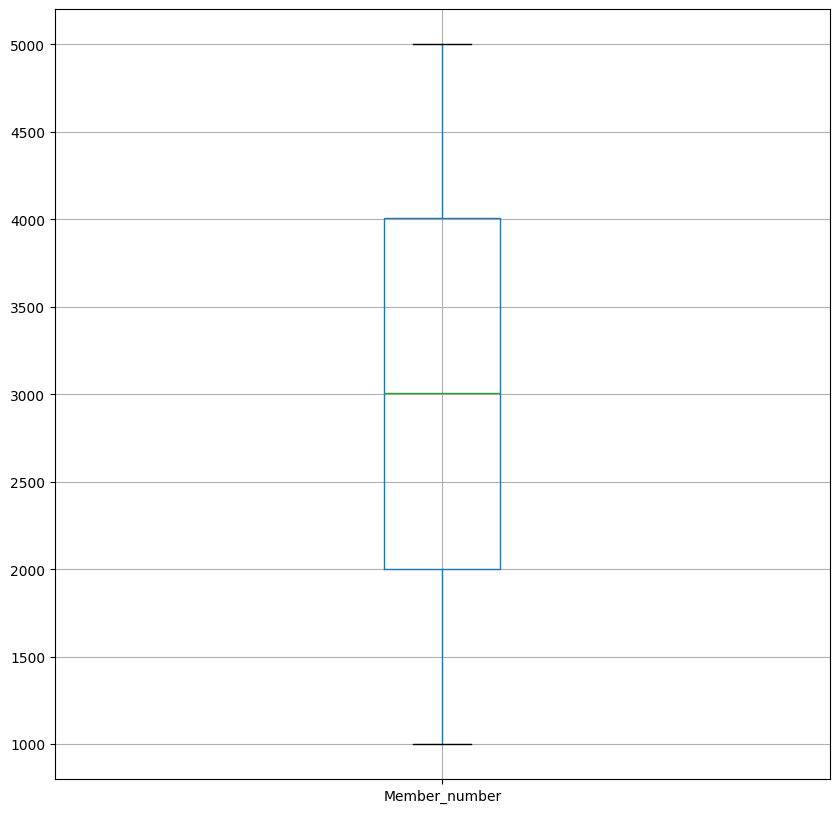

In [ ]:
#check outliers using boxplot
df.boxplot(figsize=(10,10))

In [ ]:
print("Unique transactions:", df['Member_number'].nunique())
print("Unique products:", df['itemDescription'].nunique())

Unique transactions: 3898
Unique products: 167


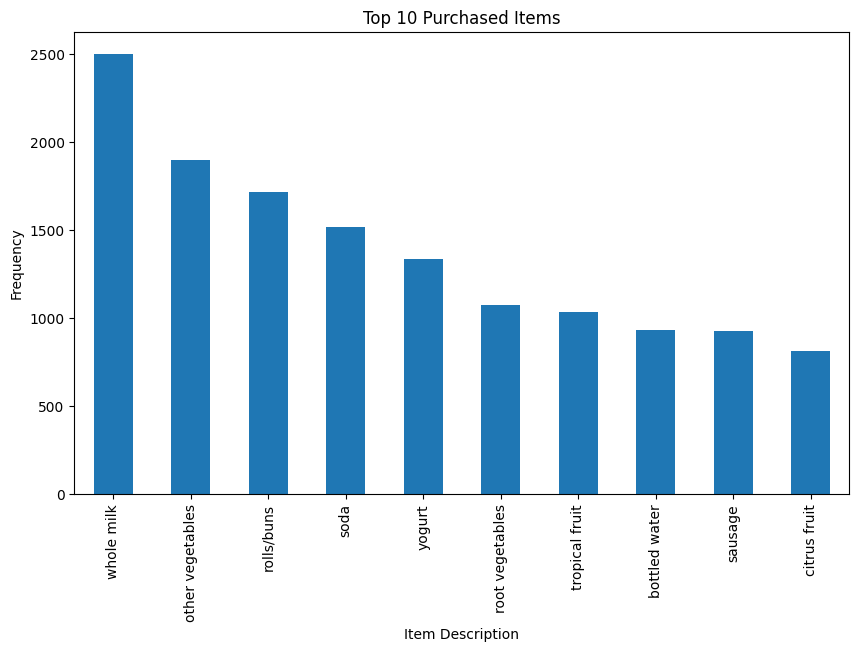

In [ ]:
top_items = df['itemDescription'].value_counts().head(10)
top_items.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Purchased Items')
plt.xlabel('Item Description')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['Transaction'] = df['Member_number'].astype(str) + '_' + df['Date'].astype(str)

basket = (
    df
    .groupby(['Transaction','itemDescription'])['itemDescription']
    .count()
    .unstack()
    .fillna(0)
)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)
print(basket.head)

<bound method NDFrame.head of itemDescription  Instant food products  UHT-milk  abrasive cleaner  \
Transaction                                                          
1000_15-03-2015                      0         0                 0   
1000_24-06-2014                      0         0                 0   
1000_24-07-2015                      0         0                 0   
1000_25-11-2015                      0         0                 0   
1000_27-05-2015                      0         0                 0   
...                                ...       ...               ...   
4999_24-01-2015                      0         0                 0   
4999_26-12-2015                      0         0                 0   
5000_09-03-2014                      0         0                 0   
5000_10-02-2015                      0         0                 0   
5000_16-11-2014                      0         0                 0   

itemDescription  artif. sweetener  baby cosmetics  bags  ba

4. Identify dependent and independent variables

no DV

iv - Date, Member_number, item description

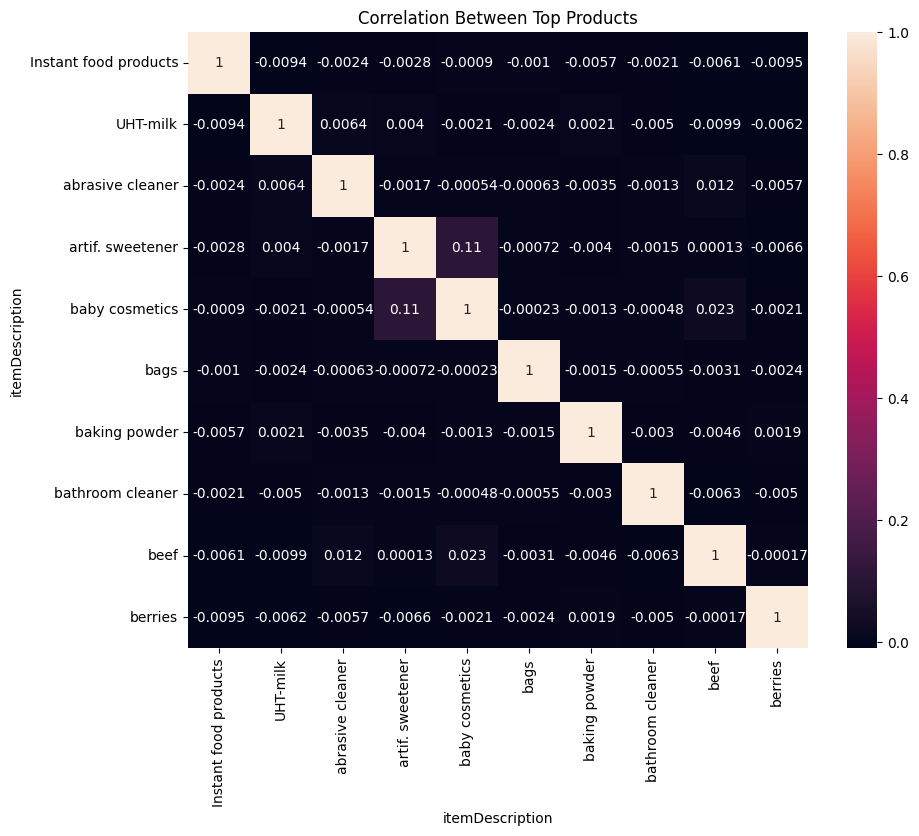

In [ ]:
#correlation between top products
top_products = basket.iloc[:,:10]
corr_matrix = top_products.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Between Top Products')
plt.show()

5. Develop Model analysis and validation

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)
print(frequent_itemsets.sort_values('support', ascending=False).head())

     support            itemsets
36  0.157923        (whole milk)
24  0.122101  (other vegetables)
28  0.110005        (rolls/buns)
32  0.097106              (soda)
37  0.085879            (yogurt)


In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

rules = rules.sort_values(by='confidence', ascending=False)
print(rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [ ]:
TRANSACTION_LEVEL = "Member date"

In [ ]:
MIN_SUPPORT = 0.01
METRIC ="lift"
MIN_THRESHOLD = 1.0
MAX_LEN = 3
TOP_N = 20
SAVE_RULES = True
OUT_RULES_CSV = "association_rules.csv"

In [ ]:
df['itemDescription'] = df['itemDescription'].astype(str).str.strip()
df = df.dropna(subset=['itemDescription'])

In [ ]:
if TRANSACTION_LEVEL == "Member date":
    baskets = (
        df.groupby(['Member_number', 'Date'])['itemDescription']
        .apply(list)
        .tolist()
    )
elif TRANSACTION_LEVEL == "member_only":
      baskets = (
          df.groupby(['Member_number'])['itemDescription']
          .apply(list)
          .tolist()
      )

else:
  raise ValueError("TRANSACTION_LEVEL must be 'member_date, or 'member_only'")

In [ ]:
baskets = [sorted(set(b)) for b in baskets if len(b)>0]
print(f"Transactions (baskets): {len(baskets)}")
print(f"Example basket: {baskets[0][:10]}{'...' if len(baskets[0])>10 else ''}")

Transactions (baskets): 14963
Example basket: ['sausage', 'semi-finished bread', 'whole milk', 'yogurt']


In [ ]:
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
basket_oh = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
freq_itemsets = apriori(basket_oh, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN).sort_values("support",ascending=False)
print(f"\nFrequent itemsets found: {len(freq_itemsets)}")
print(freq_itemsets.head(10))


Frequent itemsets found: 69
     support            itemsets
62  0.157923        (whole milk)
40  0.122101  (other vegetables)
46  0.110005        (rolls/buns)
52  0.097106              (soda)
63  0.085879            (yogurt)
47  0.069572   (root vegetables)
57  0.067767    (tropical fruit)
5   0.060683     (bottled water)
49  0.060349           (sausage)
15  0.053131      (citrus fruit)


In [ ]:
rules = association_rules(
    freq_itemsets,
    metric=METRIC,
    min_threshold=MIN_THRESHOLD
).sort_values(["lift","confidence","support"], ascending=False)

In [ ]:
rules["antecedents"] = rules["antecedents"].apply(lambda x: ', '.join(sorted(list(x))))
rules["consequents"] = rules["consequents"].apply(lambda x: ', '.join(sorted(list(x))))


In [ ]:
cols = ["antecedents", "consequents", "lift", "leverage", "support", "confidence" , "conviction"]
rules_out = rules[cols].copy()
print(f"\nRules generated: {len(rules_out)}")
print(rules_out.head(TOP_N))


Rules generated: 0
Empty DataFrame
Columns: [antecedents, consequents, lift, leverage, support, confidence, conviction]
Index: []


6. EVALUATION

In [ ]:
strong_rules = rules[
    (rules['confidence'] >= 0.6) &
    (rules['lift'] >= 1.2)
]
print(strong_rules[['antecedents','consequents','support','confidence','lift']])

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []
